In [1]:
# Standard library
from pathlib import Path
import random

# Numerical and table utilities
import numpy as np
import pandas as pd

# Image loading
import tifffile as tiff
from PIL import Image

# Plotting
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Dataset splitting
from sklearn.model_selection import train_test_split



In [2]:

from pathlib import Path

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    ROOT = Path("/content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR")
else:
    cwd = Path.cwd()

    if (cwd / "data").exists():
        ROOT = cwd
    elif (cwd.parent / "data").exists():
        ROOT = cwd.parent
    elif (cwd.parent.parent / "data").exists():
        ROOT = cwd.parent.parent
    else:
        raise FileNotFoundError("Could not find local project root containing 'data/'.")

print("IN_COLAB:", IN_COLAB)
print("ROOT:", ROOT)
print("ROOT exists:", ROOT.exists())

Mounted at /content/drive
IN_COLAB: True
ROOT: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR
ROOT exists: True


In [3]:
# Define paths to data directories

DATA_DIR = ROOT / "data"

B006_IMG = DATA_DIR / "b006" / "images"
B006_MASK = DATA_DIR / "b006" / "masks"

B039_IMG = DATA_DIR / "b039" / "images"
B039_MASK = DATA_DIR / "b039" / "masks"

COMB_IMG = DATA_DIR / "combined" / "images"
COMB_MASK = DATA_DIR / "combined" / "masks"

print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())

print("B006_IMG exists:", B006_IMG.exists())
print("B006_MASK exists:", B006_MASK.exists())

print("B039_IMG exists:", B039_IMG.exists())
print("B039_MASK exists:", B039_MASK.exists())

print("COMB_IMG exists:", COMB_IMG.exists())
print("COMB_MASK exists:", COMB_MASK.exists())

DATA_DIR: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/data
DATA_DIR exists: True
B006_IMG exists: True
B006_MASK exists: True
B039_IMG exists: True
B039_MASK exists: True
COMB_IMG exists: True
COMB_MASK exists: True


In [4]:
# Define paths to output directories and code directories

import sys

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CODE_DIR = ROOT / "FINAL_Codes"
if CODE_DIR.exists() and str(CODE_DIR) not in sys.path:
    sys.path.append(str(CODE_DIR))

print("OUT_DIR:", OUT_DIR)
print("OUT_DIR exists:", OUT_DIR.exists())
print("CODE_DIR:", CODE_DIR)
print("CODE_DIR exists:", CODE_DIR.exists())

OUT_DIR: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/outputs
OUT_DIR exists: True
CODE_DIR: /content/drive/MyDrive/ASR_Project/ASR_finalproject_AllisonWivagg_YeritmaryR/FINAL_Codes
CODE_DIR exists: True


In [5]:
#Seed and check device where its running

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [6]:
#helper functions 
def stem(path):
    return Path(path).stem


def listimgs(imgdir):
    exts = ["*.png", "*.tif", "*.tiff", "*.jpg", "*.jpeg"]
    files = []
    for ext in exts:
        files.extend(imgdir.glob(ext))
    return sorted(files)

In [7]:
#File pairing with masks

def pair_files(imgdir, maskdir, src):
    imgfiles = listimgs(Path(imgdir))
    maskfiles = listimgs(Path(maskdir))

    matched = {stem(p): p for p in imgfiles}
    rows = []

    for maskpath in maskfiles:
        image_id = stem(maskpath)
        if image_id in matched:
            rows.append({
                "image_id": image_id,
                "image_path": str(matched[image_id]),
                "mask_path": str(mask_path),
                "source": src
            })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        raise ValueError(f"No matched image-mask pairs found for source {src}")

    df = df.sort_values(["source", "image_id"]).reset_index(drop=True)
    return df

In [8]:
# Splitting data for training, validation, and test

def splitdata(df, seed=42, trainsize=0.70, validationsize=0.15, testsize=0.15):
    total = trainsize + validationsize + testsize
    
    if not np.isclose(total, 1.0):
        raise ValueError("trainsize + validationsize + testsize must sum to 1.0")

    train_df, temp_df = train_test_split(
        df,
        test_size=(1.0 - trainsize),
        random_state=seed,
        shuffle=True
    )

    test_fraction = testsize / (validationsize + testsize)

    validation_df, test_df = train_test_split(
        temp_df,
        test_size=test_fraction,
        random_state=seed,
        shuffle=True
    )

    train_df = train_df.reset_index(drop=True).copy()
    validation_df = validation_df.reset_index(drop=True).copy()
    test_df = test_df.reset_index(drop=True).copy()

    train_df["split"] = "train"
    validation_df["split"] = "val"
    test_df["split"] = "test"

    return train_df, validation_df, test_df

In [9]:
# Image reading and normalization of data

from pathlib import Path

import numpy as np
import tifffile as tiff
from PIL import Image


def readimg(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix in [".tif", ".tiff"]:
        arr = tiff.imread(str(path))
    else:
        arr = np.array(Image.open(path))

    return arr


def make2d(arr):
    arr = np.squeeze(arr)

    if arr.ndim == 2:
        return arr
    
    if arr.ndim == 3:
        return arr[..., 0]

    raise ValueError(f"Unsupported image shape: {arr.shape}")


def normalizationgray(arr):
    arr = arr.astype(np.float32)
    lo = arr.min()
    hi = arr.max()

    if hi > lo:
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    return arr


def normalizationfluo(arr, lo_q=1.0, hi_q=99.0):
    arr = arr.astype(np.float32)
    lo = np.percentile(arr, lo_q)
    hi = np.percentile(arr, hi_q)

    if hi > lo:
        arr = np.clip((arr - lo) / (hi - lo), 0, 1)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    return arr


def resizeimg(arr, size=(256, 256)):
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    out = np.array(
        pil.resize(size, Image.BILINEAR),
        dtype=np.float32
    ) / 255.0

    return out


def resizemask(arr, size=(256, 256)):
    pil = Image.fromarray((arr * 255).astype(np.uint8))
    out = np.array(
        pil.resize(size, Image.NEAREST),
        dtype=np.float32
    )

    out = (out > 0).astype(np.float32)

    return out

In [10]:
#Datset classes 

class SegSet(Dataset):
    """
    Segmentation dataset for grayscale or fluorescent image-mask pairs.
    """

    def __init__(self, df, size=(256, 256), mode="auto"):
        self.df = df.reset_index(drop=True).copy()
        self.size = size
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def _norm(self, img, src):
        mode = self.mode

        if mode == "auto":
            if "039" in src or "FLUO" in src.upper():
                mode = "fluo"
            else:
                mode = "gray"

        if mode == "gray":
            return normalizationgray(img)
        if mode == "fluo":
            return normalizationfluo(img)

        raise ValueError(f"Unsupported mode: {self.mode}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = readimg(row["image_path"])
        mask = readimg(row["mask_path"])

        img = make2d(img).astype(np.float32)
        mask = make2d(mask).astype(np.float32)

        img = self._norm(img, row["source"])
        mask = (mask > 0).astype(np.float32)

        img = resizeimg(img, self.size)
        mask = resizemask(mask, self.size)

        img = np.expand_dims(img, axis=0)
        mask = np.expand_dims(mask, axis=0)

        split = row["split"] if "split" in row.index else "na"

        return {
            "image": torch.tensor(img, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
            "image_id": row["image_id"],
            "source": row["source"],
            "split": split,
            "dataset_index": idx
        }

In [11]:
def pair_files(imgdir, maskdir, src):
    imgdir = Path(imgdir)
    maskdir = Path(maskdir)

    image_exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
    mask_exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]

    image_files = [
        p for p in imgdir.glob("*")
        if p.suffix.lower() in image_exts
    ]

    mask_files = [
        p for p in maskdir.glob("*")
        if p.suffix.lower() in mask_exts
    ]

    print("Found image files:", len(image_files))
    print("Found mask files:", len(mask_files))

    def clean_id(path):
        name = path.stem.lower()

        # remove common mask/image words
        name = name.replace("_mask", "")
        name = name.replace("-mask", "")
        name = name.replace("mask_", "")
        name = name.replace("mask-", "")
        name = name.replace("_image", "")
        name = name.replace("-image", "")
        name = name.replace("image_", "")
        name = name.replace("image-", "")
        name = name.replace("_img", "")
        name = name.replace("-img", "")

        return name

    image_dict = {clean_id(p): p for p in image_files}
    mask_dict = {clean_id(p): p for p in mask_files}

    common_ids = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    print("Matched pairs:", len(common_ids))

    if len(common_ids) == 0:
        print("\nExample cleaned image IDs:")
        for k in list(image_dict.keys())[:5]:
            print(k)

        print("\nExample cleaned mask IDs:")
        for k in list(mask_dict.keys())[:5]:
            print(k)

        raise ValueError(f"No matched image-mask pairs found for source {src}")

    rows = []

    for image_id in common_ids:
        rows.append({
            "image_id": image_id,
            "image_path": str(image_dict[image_id]),
            "mask_path": str(mask_dict[image_id]),
            "source": src
        })

    df = pd.DataFrame(rows)
    df = df.sort_values(["source", "image_id"]).reset_index(drop=True)

    return df

B039 image folder exists: True
B039 mask folder exists: True
number images: 200
number masks: 200

first 3 images:
IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.tif
IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168AA755527.tif
IXMtest_A09_s1_w1CE70AD49-290D-4312-82E6-CDC717F32637.tif

first 3 masks:
IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.png
IXMtest_A06_s6_w1B9577918-4973-4A87-BA73-A168AA755527.png
IXMtest_A09_s1_w1CE70AD49-290D-4312-82E6-CDC717F32637.png
Found image files: 200
Found mask files: 200
Matched pairs: 200

Matched pairs: 200
                                            image_id  \
0  ixmtest_a02_s1_w1051daa7c-7042-435f-99f0-1e847...   
1  ixmtest_a06_s6_w1b9577918-4973-4a87-ba73-a168a...   
2  ixmtest_a09_s1_w1ce70ad49-290d-4312-82e6-cdc71...   
3  ixmtest_a12_s7_w1eaeea614-51ed-43b3-a4ff-08873...   
4  ixmtest_a15_s5_w1825174d4-ed30-490c-9635-61964...   

                                          image_path  \
0  /content/drive/MyDrive/ASR_Project/ASR_fi

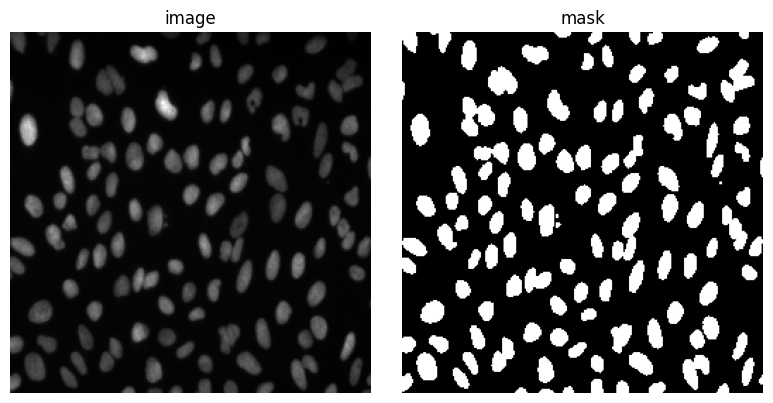

In [12]:
# Testing small dataset to see if it runs properly

print("B039 image folder exists:", B039_IMG.exists())
print("B039 mask folder exists:", B039_MASK.exists())

print("number images:", len(listimgs(B039_IMG)))
print("number masks:", len(listimgs(B039_MASK)))

print("\nfirst 3 images:")
for p in listimgs(B039_IMG)[:3]:
    print(p.name)

print("\nfirst 3 masks:")
for p in listimgs(B039_MASK)[:3]:
    print(p.name)

b039_df = pair_files(B039_IMG, B039_MASK, "BBBC039")

print("\nMatched pairs:", len(b039_df))
print(b039_df.head())

train_df, val_df, test_df = splitdata(b039_df, seed=42)

train_set = SegSet(train_df, size=(256, 256), mode="gray")
sample = train_set[0]

print("image shape:", sample["image"].shape)
print("mask shape:", sample["mask"].shape)
print("image id:", sample["image_id"])
print("source:", sample["source"])
print("split:", sample["split"])

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(sample["image"].squeeze().numpy(), cmap="gray")
plt.title("image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].squeeze().numpy(), cmap="gray")
plt.title("mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
#Wrapping the subset and loading helper
class IdxSet(Dataset):
    def __init__(self, ds, idxs):
        self.ds = ds
        self.idxs = list(idxs)

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        idx = self.idxs[i]
        item = self.ds[idx]
        item["dataset_index"] = torch.tensor(idx, dtype=torch.long)
        return item


def make_loader(ds, batch=4, shuffle=False, workers=0):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=workers)

In [14]:
#Using DoubleConv and UNet models

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, drop=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=drop),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=drop),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, feats=(32, 64, 128, 256), drop=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        ch = in_ch
        for f in feats:
            self.downs.append(DoubleConv(ch, f, drop=drop))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            ch = f

        self.bot = DoubleConv(feats[-1], feats[-1] * 2, drop=drop)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        ch = feats[-1] * 2
        for f in feats[::-1]:
            self.ups.append(nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(f + f, f, drop=drop))
            ch = f

        self.out = nn.Conv2d(feats[0], out_ch, kernel_size=1)

    def forward(self, x):
        skips = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skips.append(x)
            x = pool(x)

        x = self.bot(x)
        skips = skips[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skips[i]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.up_convs[i](x)

        return self.out(x)

In [15]:
#Verify loss metrics of IoU and Dice 

class SegLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, y):
        bce = self.bce(logits, y)

        probs = torch.sigmoid(logits)
        probs = probs.view(probs.size(0), -1)
        y = y.view(y.size(0), -1)

        inter = (probs * y).sum(dim=1)
        dice = (2.0 * inter + self.smooth) / (probs.sum(dim=1) + y.sum(dim=1) + self.smooth)
        dice_loss = 1.0 - dice.mean()

        return bce + dice_loss


def mask_scores(logits, y, thr=0.5, smooth=1e-6):
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()

    pred = pred.view(pred.size(0), -1)
    y = y.view(y.size(0), -1)

    inter = (pred * y).sum(dim=1)
    union = pred.sum(dim=1) + y.sum(dim=1) - inter

    dice = ((2.0 * inter + smooth) / (pred.sum(dim=1) + y.sum(dim=1) + smooth)).mean().item()
    iou = ((inter + smooth) / (union + smooth)).mean().item()

    return {"dice": dice, "iou": iou}

In [16]:
print("train size:", len(train_df))
print("val size:", len(val_df))
print("test size:", len(test_df))

print("train dataset size:", len(train_set))

train size: 139
val size: 30
test size: 31
train dataset size: 139


In [17]:
#Evaluate the dataset statistics and network performance on the small dataset

def evaluateNetwork(network, dataLoader, lossFunction, device):
    """
    Evaluate a segmentation model on one dataloader.

    Returns:
        Dictionary with average loss, Dice, and IoU.
    """
    network.eval()

    totalLoss = 0.0
    totalDice = 0.0
    totalIoU = 0.0
    totalBatches = 0

    with torch.no_grad():
        for batch in dataLoader:
            images = batch["image"].to(device)
            trueMasks = batch["mask"].to(device)

            predictionLogits = network(images)
            loss = lossFunction(predictionLogits, trueMasks)
            scoreTable = maskScores(predictionLogits, trueMasks)

            totalLoss += loss.item()
            totalDice += scoreTable["dice"]
            totalIoU += scoreTable["iou"]
            totalBatches += 1

    if totalBatches == 0:
        return {"loss": np.nan, "dice": np.nan, "iou": np.nan}

    return {
        "loss": totalLoss / totalBatches,
        "dice": totalDice / totalBatches,
        "iou": totalIoU / totalBatches
    }

In [18]:
#Training loop for the network and evaluating the performance of the network on the small dataset

def trainNetwork(
    network,
    trainingLoader,
    validationLoader,
    device,
    numEpochs=5,
    learningRate=1e-3,
    savingPath=None
):
    """
    Train a segmentation model and track validation performance.

    Returns:
        trained network, history table
    """
    optimizer = torch.optim.Adam(network.parameters(), lr=learningRate)
    lossFunction = SegLoss()

    bestValidationLoss = float("inf")
    historyRows = []

    for epochIndex in range(numEpochs):
        network.train()

        totalTrainingLoss = 0.0
        totalTrainingBatches = 0

        for batch in trainingLoader:
            images = batch["image"].to(device)
            trueMasks = batch["mask"].to(device)

            optimizer.zero_grad()
            predictionLogits = network(images)
            loss = lossFunction(predictionLogits, trueMasks)
            loss.backward()
            optimizer.step()

            totalTrainingLoss += loss.item()
            totalTrainingBatches += 1

        averageTrainingLoss = totalTrainingLoss / max(totalTrainingBatches, 1)
        validationScores = evaluateNetwork(
            network,
            validationLoader,
            lossFunction,
            device
        )

        historyRows.append({
            "epoch": epochIndex + 1,
            "trainLoss": averageTrainingLoss,
            "validationLoss": validationScores["loss"],
            "validationDice": validationScores["dice"],
            "validationIoU": validationScores["iou"]
        })

        print(
            f"Epoch {epochIndex + 1}/{numEpochs} | "
            f"Train Loss: {averageTrainingLoss:.4f} | "
            f"Validation Loss: {validationScores['loss']:.4f} | "
            f"Validation Dice: {validationScores['dice']:.4f} | "
            f"Validation IoU: {validationScores['iou']:.4f}"
        )

        if validationScores["loss"] < bestValidationLoss:
            bestValidationLoss = validationScores["loss"]

            if savingPath is not None:
                savingPath = Path(savingPath)
                savingPath.parent.mkdir(parents=True, exist_ok=True)
                torch.save(network.state_dict(), savingPath)

    if savingPath is not None and Path(savingPath).exists():
        network.load_state_dict(torch.load(savingPath, map_location=device))

    historyTable = pd.DataFrame(historyRows)
    return network, historyTable

In [19]:
#Indexing the dataset 
#subset and dataloader helpers for training and evaluation

class IndexedSet(Dataset):
    """
    Thin wrapper that keeps only selected dataset indices.
    """

    def __init__(self, dataset, selectedIndices):
        self.dataset = dataset
        self.selectedIndices = list(selectedIndices)

    def __len__(self):
        return len(self.selectedIndices)

    def __getitem__(self, index):
        datasetIndex = self.selectedIndices[index]
        item = self.dataset[datasetIndex]
        item["dataset_index"] = torch.tensor(datasetIndex, dtype=torch.long)
        return item


def makeLoader(dataset, batchSize=4, shuffle=False, numWorkers=0):
    """
    Build a DataLoader.
    """
    return DataLoader(
        dataset,
        batch_size=batchSize,
        shuffle=shuffle,
        num_workers=numWorkers
    )


In [20]:
#Pool initialization and updating for active learning

def initializePool(trainingSet, initialLabeledSize=20, seed=42):
    """
    Create initial labeled and unlabeled pools.
    """
    randomGenerator = np.random.default_rng(seed)
    allIndices = np.arange(len(trainingSet))
    randomGenerator.shuffle(allIndices)

    initialLabeledSize = min(initialLabeledSize, len(allIndices))

    labeledIndices = allIndices[:initialLabeledSize].tolist()
    unlabeledIndices = allIndices[initialLabeledSize:].tolist()

    return labeledIndices, unlabeledIndices


def updatePool(labeledIndices, unlabeledIndices, selectedIndices):
    """
    Move selected indices from unlabeled pool to labeled pool.
    """
    selectedSet = set(selectedIndices)

    updatedLabeledIndices = labeledIndices + [
        index for index in selectedIndices if index not in labeledIndices
    ]
    updatedUnlabeledIndices = [
        index for index in unlabeledIndices if index not in selectedSet
    ]

    return updatedLabeledIndices, updatedUnlabeledIndices

In [21]:
#Monte carlo dropout for uncertainty estimation

def enableDropout(network):
    """
    Turn dropout layers on during inference for Monte Carlo dropout.
    """
    for module in network.modules():
        if isinstance(module, (nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
            module.train()


@torch.no_grad()
def monteCarloPredictions(network, images, device, numMonteCarloRuns=10):
    """
    Run Monte Carlo dropout predictions.

    Returns:
        Tensor of shape [numMonteCarloRuns, batch, 1, H, W]
    """
    network.eval()
    enableDropout(network)

    images = images.to(device)
    predictionList = []

    for _ in range(numMonteCarloRuns):
        predictionLogits = network(images)
        predictionProbabilities = torch.sigmoid(predictionLogits)
        predictionList.append(predictionProbabilities.cpu())

    monteCarloTensor = torch.stack(predictionList, dim=0)
    return monteCarloTensor


def uncertaintyScore(monteCarloTensor):
    """
    Compute image-level uncertainty as mean pixel variance.
    """
    varianceTensor = torch.var(monteCarloTensor, dim=0)
    imageUncertainty = varianceTensor.mean(dim=(1, 2, 3))
    return imageUncertainty.numpy()

In [22]:
#Ranking the unlabeled data by uncertainty and picking the most uncertain examples for labeling

def rankUnlabeled(network, unlabeledLoader, device, numMonteCarloRuns=10):
    """
    Score unlabeled images by uncertainty.
    """
    rankingRows = []
    totalBatches = len(unlabeledLoader)

    for batchIndex, batch in enumerate(unlabeledLoader):
        if batchIndex % 10 == 0 or batchIndex == totalBatches - 1:
            print(f"Scoring unlabeled batch {batchIndex + 1}/{totalBatches}")

        images = batch["image"].to(device)
        datasetIndices = batch["dataset_index"]
        imageIds = batch["image_id"]

        monteCarloTensor = monteCarloPredictions(
            network,
            images,
            device=device,
            numMonteCarloRuns=numMonteCarloRuns
        )
        uncertaintyValues = uncertaintyScore(monteCarloTensor)

        for indexInBatch in range(len(uncertaintyValues)):
            datasetIndex = (
                int(datasetIndices[indexInBatch].item())
                if torch.is_tensor(datasetIndices[indexInBatch])
                else int(datasetIndices[indexInBatch])
            )

            rankingRows.append({
                "datasetIndex": datasetIndex,
                "imageId": imageIds[indexInBatch],
                "uncertaintyScore": float(uncertaintyValues[indexInBatch])
            })

    rankingTable = pd.DataFrame(rankingRows)
    return rankingTable


def topPick(rankingTable, selectionCount):
    """
    Pick the most uncertain examples.
    """
    if len(rankingTable) == 0:
        return pd.DataFrame(columns=["datasetIndex", "imageId", "uncertaintyScore"])

    selectedTable = (
        rankingTable
        .sort_values("uncertaintyScore", ascending=False)
        .head(selectionCount)
        .reset_index(drop=True)
    )

    return selectedTable

In [23]:
#One active learnign round 

def activeRound(
    trainingSet,
    validationSet,
    labeledIndices,
    unlabeledIndices,
    device,
    selectionBatchSize=10,
    batchSize=4,
    numEpochs=5,
    learningRate=1e-3,
    numMonteCarloRuns=5,
    dropoutRate=0.3,
    savingPath="activeRoundBest.pt"
):
    """
    Run one active learning round.
    """
    network = UNet(in_ch=1, out_ch=1, drop=dropoutRate).to(device)

    trainingLoader = makeLoader(
        IndexedSet(trainingSet, labeledIndices),
        batchSize=batchSize,
        shuffle=True
    )
    validationLoader = makeLoader(
        validationSet,
        batchSize=batchSize,
        shuffle=False
    )

    network, historyTable = trainNetwork(
        network,
        trainingLoader,
        validationLoader,
        device=device,
        numEpochs=numEpochs,
        learningRate=learningRate,
        savingPath=savingPath
    )

    if len(unlabeledIndices) == 0:
        emptyTable = pd.DataFrame(columns=["datasetIndex", "imageId", "uncertaintyScore"])
        return network, historyTable, emptyTable, emptyTable, []

    unlabeledLoader = makeLoader(
        IndexedSet(trainingSet, unlabeledIndices),
        batchSize=batchSize,
        shuffle=False
    )

    rankingTable = rankUnlabeled(
        network,
        unlabeledLoader,
        device=device,
        numMonteCarloRuns=numMonteCarloRuns
    )

    selectedTable = topPick(
        rankingTable,
        selectionCount=min(selectionBatchSize, len(unlabeledIndices))
    )

    selectedIndices = (
        selectedTable["datasetIndex"].tolist()
        if len(selectedTable) > 0
        else []
    )

    return network, historyTable, rankingTable, selectedTable, selectedIndices

In [24]:
#Full active learning loop that runs multiple rounds of training, ranking, and selection

def runActiveLearning(
    trainingSet,
    validationSet,
    testSet,
    device,
    initialLabeledSize=20,
    selectionBatchSize=10,
    numRounds=3,
    batchSize=4,
    numEpochs=5,
    learningRate=1e-3,
    numMonteCarloRuns=5,
    dropoutRate=0.3,
    seed=42,
    outputDirectory=None
):
    """
    Run the full active learning loop.
    """
    labeledIndices, unlabeledIndices = initializePool(
        trainingSet,
        initialLabeledSize=initialLabeledSize,
        seed=seed
    )

    historyRows = []
    finalUNet = None

    for roundIndex in range(numRounds):
        print(f"\n=== Active Learning Round {roundIndex + 1}/{numRounds} ===")
        print("Current labeled size:", len(labeledIndices))
        print("Current unlabeled size:", len(unlabeledIndices))

        if outputDirectory is not None:
            savingPath = Path(outputDirectory) / f"activeRound{roundIndex + 1}Best.pt"
        else:
            savingPath = f"activeRound{roundIndex + 1}Best.pt"

        network, historyTable, rankingTable, selectedTable, selectedIndices = activeRound(
            trainingSet=trainingSet,
            validationSet=validationSet,
            labeledIndices=labeledIndices,
            unlabeledIndices=unlabeledIndices,
            device=device,
            selectionBatchSize=selectionBatchSize,
            batchSize=batchSize,
            numEpochs=numEpochs,
            learningRate=learningRate,
            numMonteCarloRuns=numMonteCarloRuns,
            dropoutRate=dropoutRate,
            savingPath=savingPath
        )

        testLoader = makeLoader(testSet, batchSize=batchSize, shuffle=False)
        testScores = evaluateNetwork(
            network,
            testLoader,
            SegLoss(),
            device
        )

        historyRows.append({
            "round": roundIndex + 1,
            "labeledSize": len(labeledIndices),
            "unlabeledSize": len(unlabeledIndices),
            "numSelectedThisRound": len(selectedIndices),
            "meanSelectedUncertainty": (
                selectedTable["uncertaintyScore"].mean()
                if len(selectedTable) > 0 else np.nan
            ),
            "testLoss": testScores["loss"],
            "testDice": testScores["dice"],
            "testIoU": testScores["iou"]
        })

        labeledIndices, unlabeledIndices = updatePool(
            labeledIndices,
            unlabeledIndices,
            selectedIndices
        )

        finalUNet = network

        if len(unlabeledIndices) == 0:
            print("unlabeled pool is empty, stopping early")
            break

    historyTable = pd.DataFrame(historyRows)

    if outputDirectory is not None:
        Path(outputDirectory).mkdir(parents=True, exist_ok=True)
        historyTable.to_csv(Path(outputDirectory) / "activeHistory.csv", index=False)

    return finalUNet, historyTable, labeledIndices, unlabeledIndices

In [25]:
#Passive learning loop that trains on random samples instead of uncertain samples

def randomPick(unlabeledIndices, selectionCount, seed=42):
    """
    Randomly select unlabeled indices.
    """
    randomGenerator = np.random.default_rng(seed)

    if len(unlabeledIndices) == 0:
        return []

    selectionCount = min(selectionCount, len(unlabeledIndices))
    return randomGenerator.choice(
        list(unlabeledIndices),
        size=selectionCount,
        replace=False
    ).tolist()


def passiveRound(
    trainingSet,
    validationSet,
    labeledIndices,
    unlabeledIndices,
    device,
    selectionBatchSize=10,
    batchSize=4,
    numEpochs=5,
    learningRate=1e-3,
    dropoutRate=0.3,
    seed=42,
    savingPath="passiveRoundBest.pt"
):
    """
    Run one passive learning round.
    """
    network = UNet(in_ch=1, out_ch=1, drop=dropoutRate).to(device)

    trainingLoader = makeLoader(
        IndexedSet(trainingSet, labeledIndices),
        batchSize=batchSize,
        shuffle=True
    )
    validationLoader = makeLoader(
        validationSet,
        batchSize=batchSize,
        shuffle=False
    )

    network, historyTable = trainNetwork(
        network,
        trainingLoader,
        validationLoader,
        device=device,
        numEpochs=numEpochs,
        learningRate=learningRate,
        savingPath=savingPath
    )

    selectedIndices = randomPick(
        unlabeledIndices,
        selectionCount=selectionBatchSize,
        seed=seed
    )

    selectedRows = []
    for datasetIndex in selectedIndices:
        row = trainingSet.df.iloc[datasetIndex]
        selectedRows.append({
            "datasetIndex": datasetIndex,
            "imageId": row["image_id"]
        })

    selectedTable = pd.DataFrame(selectedRows)

    return network, historyTable, selectedTable, selectedIndices


def runPassiveLearning(
    trainingSet,
    validationSet,
    testSet,
    device,
    initialLabeledSize=20,
    selectionBatchSize=10,
    numRounds=3,
    batchSize=4,
    numEpochs=5,
    learningRate=1e-3,
    dropoutRate=0.3,
    seed=42,
    outputDirectory=None
):
    """
    Run the full passive learning loop.
    """
    labeledIndices, unlabeledIndices = initializePool(
        trainingSet,
        initialLabeledSize=initialLabeledSize,
        seed=seed
    )

    historyRows = []
    finalUNet = None

    for roundIndex in range(numRounds):
        print(f"\n=== Passive Learning Round {roundIndex + 1}/{numRounds} ===")
        print("Current labeled size:", len(labeledIndices))
        print("Current unlabeled size:", len(unlabeledIndices))

        if outputDirectory is not None:
            savingPath = Path(outputDirectory) / f"passiveRound{roundIndex + 1}Best.pt"
        else:
            savingPath = f"passiveRound{roundIndex + 1}Best.pt"

        network, historyTable, selectedTable, selectedIndices = passiveRound(
            trainingSet=trainingSet,
            validationSet=validationSet,
            labeledIndices=labeledIndices,
            unlabeledIndices=unlabeledIndices,
            device=device,
            selectionBatchSize=selectionBatchSize,
            batchSize=batchSize,
            numEpochs=numEpochs,
            learningRate=learningRate,
            dropoutRate=dropoutRate,
            seed=seed + roundIndex,
            savingPath=savingPath
        )

        testLoader = makeLoader(testSet, batchSize=batchSize, shuffle=False)
        testScores = evaluateNetwork(
            network,
            testLoader,
            SegLoss(),
            device
        )

        historyRows.append({
            "round": roundIndex + 1,
            "labeledSize": len(labeledIndices),
            "unlabeledSize": len(unlabeledIndices),
            "numSelectedThisRound": len(selectedIndices),
            "testLoss": testScores["loss"],
            "testDice": testScores["dice"],
            "testIoU": testScores["iou"]
        })

        labeledIndices, unlabeledIndices = updatePool(
            labeledIndices,
            unlabeledIndices,
            selectedIndices
        )

        finalUNet = network

        if len(unlabeledIndices) == 0:
            print("unlabeled pool is empty, stopping early")
            break

    historyTable = pd.DataFrame(historyRows)

    if outputDirectory is not None:
        Path(outputDirectory).mkdir(parents=True, exist_ok=True)
        historyTable.to_csv(Path(outputDirectory) / "passiveHistory.csv", index=False)

    return finalUNet, historyTable, labeledIndices, unlabeledIndices

In [26]:
#Scoring the predictions of the network on a per-image basis and comparing the scores of the active and passive learning approaches
def scorePerImage(predictedMask, trueMask, smooth=1e-6):
    predictedMask = predictedMask.reshape(-1).astype(np.float32)
    trueMask = trueMask.reshape(-1).astype(np.float32)

    intersection = (predictedMask * trueMask).sum()
    union = predictedMask.sum() + trueMask.sum() - intersection

    diceScore = (2.0 * intersection + smooth) / (
        predictedMask.sum() + trueMask.sum() + smooth
    )
    iouScore = (intersection + smooth) / (union + smooth)

    return float(diceScore), float(iouScore)


def imageScores(network, dataset, device, threshold=0.5):
    """
    Compute per-image Dice and IoU for one model on one dataset.
    """
    network.eval()
    scoreRows = []

    with torch.no_grad():
        for datasetIndex in range(len(dataset)):
            sample = dataset[datasetIndex]

            images = sample["image"].unsqueeze(0).to(device)
            trueMask = sample["mask"].squeeze().cpu().numpy()

            predictionLogits = network(images)
            predictedMask = (
                (torch.sigmoid(predictionLogits) > threshold)
                .float()
                .squeeze()
                .cpu()
                .numpy()
            )

            diceScore, iouScore = scorePerImage(predictedMask, trueMask)

            scoreRows.append({
                "datasetIndex": int(sample["dataset_index"]),
                "imageId": sample["image_id"],
                "source": sample["source"],
                "dice": diceScore,
                "iou": iouScore
            })

    return pd.DataFrame(scoreRows)


def mergeScores(activeScoreTable, passiveScoreTable):
    comparisonTable = activeScoreTable.merge(
        passiveScoreTable,
        on=["datasetIndex", "imageId", "source"],
        suffixes=("_active", "_passive")
    )

    comparisonTable["iouGainActiveMinusPassive"] = (
        comparisonTable["iou_active"] - comparisonTable["iou_passive"]
    )
    comparisonTable["diceGainActiveMinusPassive"] = (
        comparisonTable["dice_active"] - comparisonTable["dice_passive"]
    )

    return comparisonTable

In [27]:
#Visualize the predictions of the active and passive models side by side for a fixed list of image ids, along with the raw image and ground truth mask.

def compareImagesById(
    activeNetwork,
    passiveNetwork,
    dataset,
    device,
    imageIds,
    threshold=0.5
):
    """
    Show raw image, ground truth, active prediction, and passive prediction
    for a fixed list of image ids.
    """
    activeNetwork.eval()
    passiveNetwork.eval()

    fig, axes = plt.subplots(len(imageIds), 4, figsize=(14, 4 * len(imageIds)))

    if len(imageIds) == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for rowIndex, imageId in enumerate(imageIds):
            matches = dataset.df.index[dataset.df["image_id"] == imageId].tolist()

            if len(matches) == 0:
                print(f"imageId not found: {imageId}")
                continue

            datasetIndex = matches[0]
            sample = dataset[datasetIndex]

            images = sample["image"].unsqueeze(0).to(device)
            truth = sample["mask"].squeeze().cpu().numpy()
            prediction = sample["image"].squeeze().cpu().numpy()

            activePrediction = (
                (torch.sigmoid(activeNetwork(images)) > threshold)
                .float()
                .squeeze()
                .cpu()
                .numpy()
            )

            passivePrediction = (
                (torch.sigmoid(passiveNetwork(images)) > threshold)
                .float()
                .squeeze()
                .cpu()
                .numpy()
            )

            axes[rowIndex, 0].imshow(prediction, cmap="gray")
            axes[rowIndex, 0].set_title(f"Raw\nidx={datasetIndex}\nid={sample['image_id']}")
            axes[rowIndex, 0].axis("off")

            axes[rowIndex, 1].imshow(truth, cmap="gray")
            axes[rowIndex, 1].set_title("Ground Truth")
            axes[rowIndex, 1].axis("off")

            axes[rowIndex, 2].imshow(activePrediction, cmap="gray")
            axes[rowIndex, 2].set_title("Active")
            axes[rowIndex, 2].axis("off")

            axes[rowIndex, 3].imshow(passivePrediction, cmap="gray")
            axes[rowIndex, 3].set_title("Passive")
            axes[rowIndex, 3].axis("off")

    plt.tight_layout()
    plt.show()


def plotIoU(comparisonTable, title="IoU Comparison"):
    plt.figure(figsize=(10, 5))
    plt.plot(
        comparisonTable["datasetIndex"],
        comparisonTable["iou_passive"],
        label="Passive vs Ground Truth"
    )
    plt.plot(
        comparisonTable["datasetIndex"],
        comparisonTable["iou_active"],
        label="Active vs Ground Truth"
    )
    plt.xlabel("Image ID")
    plt.ylabel("Intersection over Union (IoU)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plotDice(comparisonTable, title="Dice Comparison"):
    plt.figure(figsize=(10, 5))
    plt.plot(
        comparisonTable["datasetIndex"],
        comparisonTable["dice_passive"],
        label="Passive vs Ground Truth"
    )
    plt.plot(
        comparisonTable["datasetIndex"],
        comparisonTable["dice_active"],
        label="Active vs Ground Truth"
    )
    plt.xlabel("Image ID")
    plt.ylabel("Dice")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

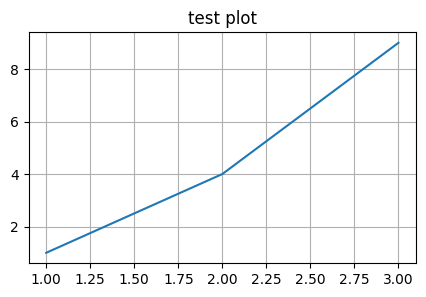

In [30]:
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [1, 4, 9])
plt.title("test plot")
plt.grid(True)
plt.show()

In [ ]:
# Score predictions from both models
activeScoreTable = imageScores(activeNetwork, testSet, device)
passiveScoreTable = imageScores(passiveNetwork, testSet, device)

# Merge and compare scores
comparisonTable = mergeScores(activeScoreTable, passiveScoreTable)

plotIoU(comparisonTable, title="IoU Comparison")
plotDice(comparisonTable, title="Dice Comparison")